# PA / PB1 peptide design — run2_wide + run_multimer comparison

Loads ColabDesign generation/optimisation results from **both** `results/run2_wide`
and `results/run_multimer`, then compares protocols on ColabDesign metrics
(loss, energy, i_ptm, ptm, plddt).  No Boltz predictions are used.

In [1]:
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Paths

In [ ]:
import sys, os, pathlib

# Load .env from project root (one level up from notebooks/)
_env_path = pathlib.Path('..') / '.env'
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line.startswith('export '):
            _line = _line[7:]
        if '=' in _line and not _line.startswith('#'):
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip())

sys.path.append('..')
import config

PRJ_DIR    = pathlib.Path('..').resolve()
SCRIPT_DIR = PRJ_DIR / 'notebooks'
COLAB_DIR  = pathlib.Path(config.RESULTS_DIR)

# Auto-discover all subdirectories under COLAB_DIR
COLAB_DIRS = {d.name: d for d in sorted(COLAB_DIR.iterdir()) if d.is_dir()}

for run, d in COLAB_DIRS.items():
    n = len(list(d.glob('*.json')))
    print(f'{run:30s}  ({n} JSON files)')

## 2. Load ColabDesign results

In [ ]:
def load_colab_results(colab_dir: pathlib.Path, source: str) -> pd.DataFrame:
    model = 'af2_multimer' if 'multimer' in source else 'af2'
    rows = []
    for jf in sorted(colab_dir.glob('*.json')):
        proto = jf.stem
        data  = json.loads(jf.read_text())
        for i, entry in enumerate(data.get('results', [])):
            rows.append({
                'source'     : source,
                'model'      : model,
                'group'      : f'{source}/{proto}',
                'name'       : f'{source}/{proto}_{i}',
                'protocol'   : proto,
                'idx'        : i,
                'seq'        : entry.get('seq', ''),
                'loss_total' : entry.get('loss_total'),
                'loss_af'    : entry.get('loss_af'),
                'energy'     : entry.get('energy'),
                'colab_iptm' : entry.get('i_ptm'),
                'colab_ptm'  : entry.get('ptm'),
                'colab_plddt': entry.get('plddt'),
            })
    if not rows:
        print(f'  [empty] {source}: no results found in {colab_dir}')
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    print(f'{source:30s}  model={model}  {len(df):4d} entries  ({df["protocol"].nunique()} protocols)')
    return df

frames = []
for run_name, run_dir in COLAB_DIRS.items():
    frames.append(load_colab_results(run_dir, run_name))

df = pd.concat([f for f in frames if not f.empty], ignore_index=True)
print(f'\nTotal: {len(df)} entries from {df["group"].nunique()} (source, protocol) groups')
df.head()

## 3. Per-group summary statistics

In [4]:
METRICS = ['loss_af', 'energy', 'colab_iptm', 'colab_ptm', 'colab_plddt']
available = [m for m in METRICS if m in df.columns and df[m].notna().any()]

summary = (
    df.groupby('group')[available]
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(3)
)
summary

loss_af                         energy        \
                                    mean   std   min   max count   mean   std   
group                                                                           
run2_wide/gen_energy_A             3.965 0.150 3.749 4.293    28 -3.468 1.224   
run2_wide/gen_energy_C             3.983 0.273 3.206 4.574    29 -6.598 1.180   
run2_wide/opt_anneal_energy_B      5.161 0.631 3.975 6.562    65 -1.727 2.047   
run2_wide/opt_anneal_energy_C      5.101 0.675 3.815 6.740    65 -2.465 2.184   
run2_wide/opt_anneal_noenergy      5.127 0.730 2.977 6.245    65  1.096 3.552   
run2_wide/opt_hard_energy_C        5.972 0.722 4.714 7.420    31 -1.455 2.600   
run_multimer/gen_energy_C          4.233 0.729 3.116 6.107    17 -5.813 1.364   
run_multimer/opt_anneal_energy_C   5.101 0.675 3.815 6.740    65 -2.465 2.184   
run_multimer/opt_anneal_noenergy   5.127 0.730 2.977 6.245    65  1.096 3.552   

                                                      ... colab_ptm        \
                                    min    max count  ...      mean   std   
group                                                 ...                   
run2_wide/gen_energy_A           -5.680 -1.082    28  ...     0.888 0.003   
run2_wide/gen_energy_C           -8.276 -4.303    29  ...     0.889 0.005   
run2_wide/opt_anneal_energy_B    -5.568  4.326    65  ...     0.881 0.002   
run2_wide/opt_anneal_energy_C    -6.568  4.008    65  ...     0.881 0.003   
run2_wide/opt_anneal_noenergy    -4.404  8.271    65  ...     0.882 0.004   
run2_wide/opt_hard_energy_C      -4.834  5.943    31  ...     0.886 0.001   
run_multimer/gen_energy_C        -8.661 -3.584    17  ...     0.863 0.008   
run_multimer/opt_anneal_energy_C -6.568  4.008    65  ...     0.881 0.003   
run_multimer/opt_anneal_noenergy -4.404  8.271    65  ...     0.882 0.004   

                                                   colab_plddt              \
                                   min   max count        mean   std   min   
group                                                                        
run2_wide/gen_energy_A           0.880 0.896    28       0.385 0.034 0.341   
run2_wide/gen_energy_C           0.879 0.901    29       0.388 0.042 0.330   
run2_wide/opt_anneal_energy_B    0.875 0.885    65       0.335 0.044 0.279   
run2_wide/opt_anneal_energy_C    0.879 0.889    65       0.334 0.028 0.285   
run2_wide/opt_anneal_noenergy    0.875 0.895    65       0.343 0.051 0.280   
run2_wide/opt_hard_energy_C      0.885 0.888    31       0.360 0.047 0.290   
run_multimer/gen_energy_C        0.854 0.883    17       0.308 0.069 0.223   
run_multimer/opt_anneal_energy_C 0.879 0.889    65       0.334 0.028 0.285   
run_multimer/opt_anneal_noenergy 0.875 0.895    65       0.343 0.051 0.280   

                                              
                                   max count  
group                                         
run2_wide/gen_energy_A           0.498    28  
run2_wide/gen_energy_C           0.501    29  
run2_wide/opt_anneal_energy_B    0.534    65  
run2_wide/opt_anneal_energy_C    0.401    65  
run2_wide/opt_anneal_noenergy    0.530    65  
run2_wide/opt_hard_energy_C      0.473    31  
run_multimer/gen_energy_C        0.521    17  
run_multimer/opt_anneal_energy_C 0.401    65  
run_multimer/opt_anneal_noenergy 0.530    65  

[9 rows x 25 columns]

## 4. Visualisations
### 4.1 Box plots — ColabDesign metrics by group

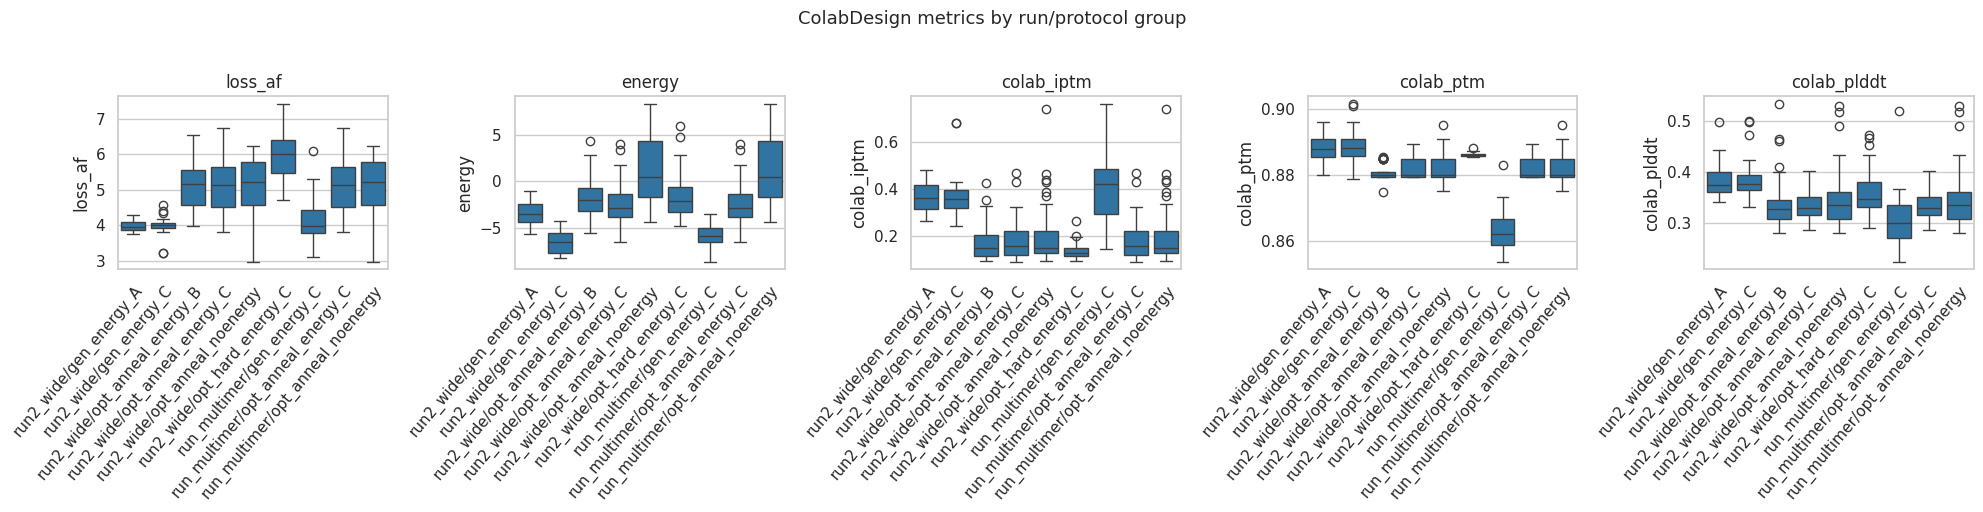

In [5]:
colab_metrics = [m for m in ['loss_af', 'energy', 'colab_iptm', 'colab_ptm', 'colab_plddt']
                 if m in df.columns]

groups = sorted(df['group'].unique())

fig, axes = plt.subplots(1, len(colab_metrics), figsize=(4*len(colab_metrics), 5), sharey=False)
for ax, metric in zip(axes, colab_metrics):
    sns.boxplot(data=df, x='group', y=metric, ax=ax, order=groups)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=50)
    plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
fig.suptitle('ColabDesign metrics by run/protocol group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Box plots — split by source (run2_wide vs run_multimer)

For protocols that appear in both runs, this shows side-by-side distributions.

Protocols present in both runs: ['gen_energy_C', 'opt_anneal_energy_C', 'opt_anneal_noenergy']


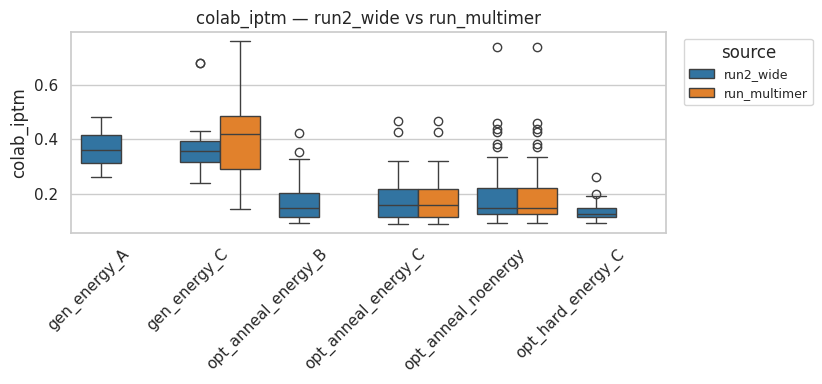

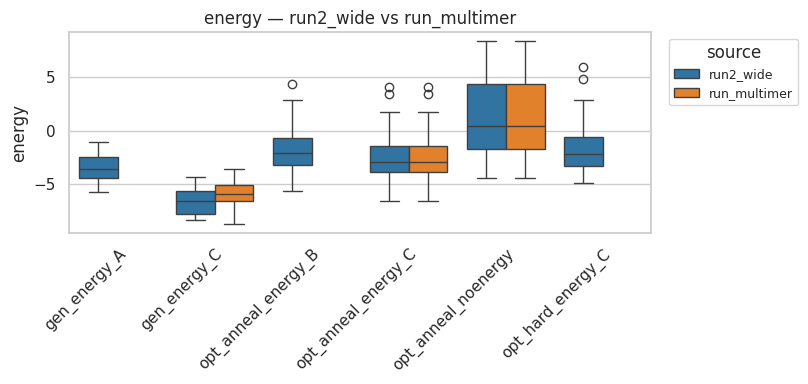

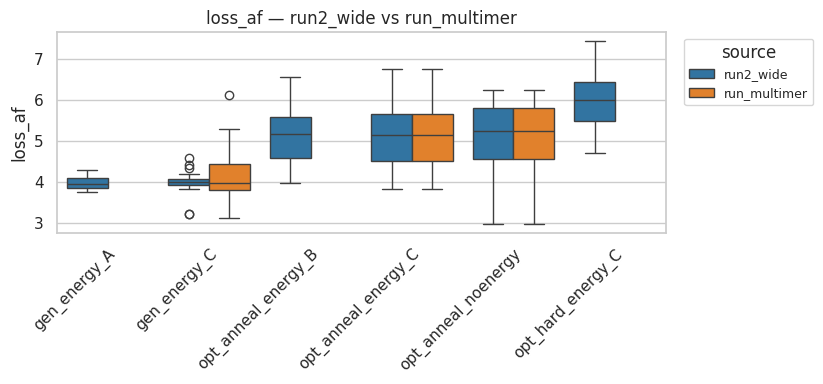

In [6]:
shared_protocols = (
    df.groupby('protocol')['source'].nunique()
    .pipe(lambda s: s[s > 1].index.tolist())
)
print(f'Protocols present in both runs: {shared_protocols or "none"}')

for metric in ['colab_iptm', 'energy', 'loss_af']:
    if metric not in df.columns:
        continue
    protos = sorted(df['protocol'].unique())
    fig, ax = plt.subplots(figsize=(max(6, len(protos)*1.4), 4))
    sns.boxplot(data=df, x='protocol', y=metric, hue='source',
                order=protos, ax=ax)
    ax.set_title(f'{metric} — run2_wide vs run_multimer')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    ax.legend(title='source', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

### 4.3 Group ranking — mean colab_iptm

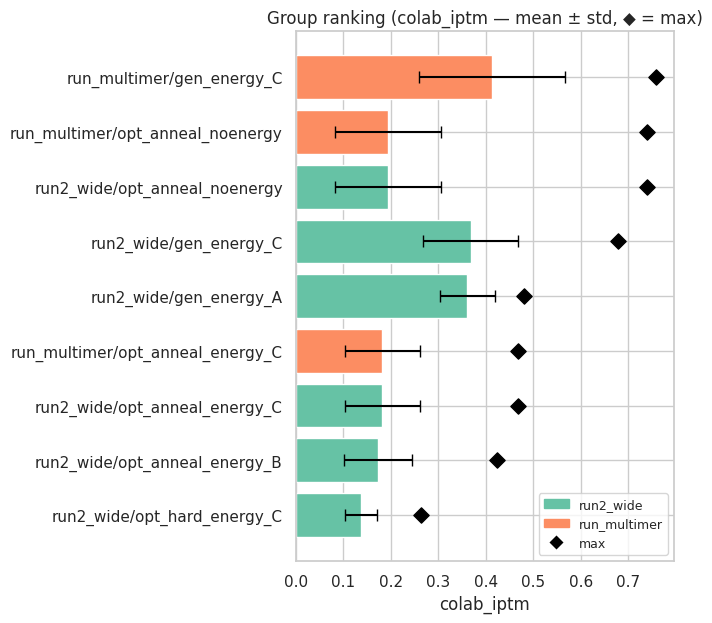

,mean,std,count,max
group,,,,
run_multimer/gen_energy_C,0.413,0.153,17,0.759
run_multimer/opt_anneal_noenergy,0.194,0.112,65,0.739
run2_wide/opt_anneal_noenergy,0.194,0.112,65,0.739
run2_wide/gen_energy_C,0.368,0.100,29,0.678
run2_wide/gen_energy_A,0.361,0.058,28,0.481
run_multimer/opt_anneal_energy_C,0.182,0.080,65,0.467
run2_wide/opt_anneal_energy_C,0.182,0.080,65,0.467
run2_wide/opt_anneal_energy_B,0.172,0.072,65,0.425
run2_wide/opt_hard_energy_C,0.137,0.035,31,0.263


In [7]:
rank = (
    df.groupby('group')['colab_iptm']
    .agg(['mean', 'std', 'count', 'max'])
    .sort_values('max', ascending=False)
)

# colour by source
source_of = df.drop_duplicates('group').set_index('group')['source']
sources   = sorted(source_of.unique())
src_colors = dict(zip(sources, sns.color_palette('Set2', len(sources))))
bar_colors = [src_colors[source_of[g]] for g in rank.index]

fig, ax = plt.subplots(figsize=(7, 0.6*len(rank)+1))
ax.barh(rank.index, rank['mean'], xerr=rank['std'], align='center',
        color=bar_colors, capsize=4)
ax.scatter(rank['max'], rank.index, color='black', zorder=5,
           s=60, marker='D', label='max')

# legend for source colours
from matplotlib.patches import Patch
legend_patches = [Patch(color=src_colors[s], label=s) for s in sources]
legend_patches.append(plt.Line2D([0],[0], marker='D', color='w',
                                  markerfacecolor='black', label='max', markersize=8))
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_xlabel('colab_iptm')
ax.set_title('Group ranking (colab_iptm — mean ± std, ◆ = max)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(rank)

### 4.4 Heatmap — mean metrics per group

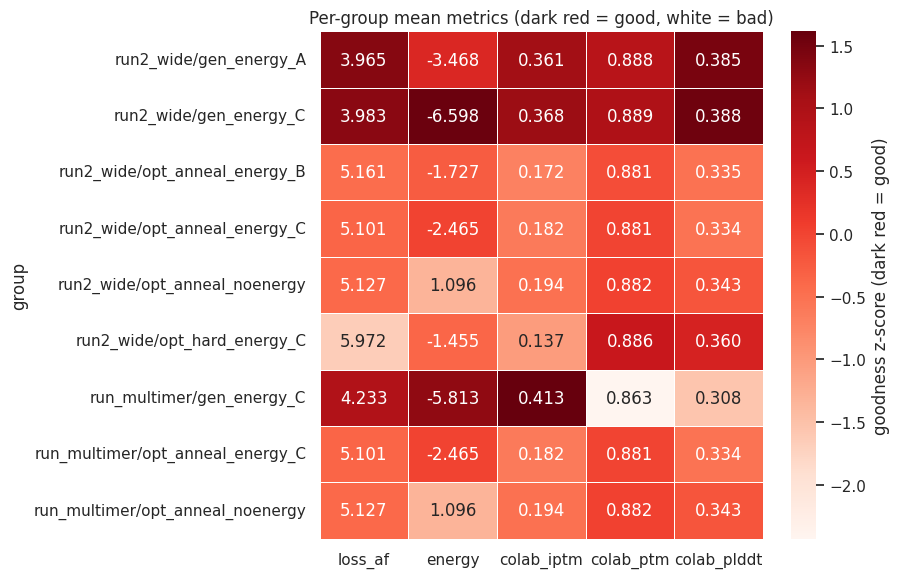

In [8]:
heat_cols = [m for m in ['loss_af', 'energy', 'colab_iptm', 'colab_ptm', 'colab_plddt']
             if m in df.columns and df[m].notna().any()]

heat   = df.groupby('group')[heat_cols].mean()

LOWER_IS_BETTER = {'loss_af', 'energy', 'loss_total'}
heat_z = (heat - heat.mean()) / heat.std()
for col in heat_z.columns:
    if col in LOWER_IS_BETTER:
        heat_z[col] = -heat_z[col]

fig, ax = plt.subplots(figsize=(len(heat_cols)*1.6+1, len(heat)*0.55+1))
sns.heatmap(heat_z, annot=heat.round(3), fmt='.3f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'goodness z-score (dark red = good)'})
ax.set_title('Per-group mean metrics (dark red = good, white = bad)')
plt.tight_layout()
plt.show()

## 5. Top candidates

In [9]:
sort_col = 'colab_iptm'
print(f'Ranking by: {sort_col}')

top = (
    df.dropna(subset=[sort_col])
    .sort_values(sort_col, ascending=False)
    .head(20)[['name', 'source', 'protocol', 'seq',
               'loss_total', 'loss_af', 'energy',
               'colab_iptm', 'colab_ptm', 'colab_plddt']]
    .reset_index(drop=True)
)
display(top)

Ranking by: colab_iptm


,name,source,protocol,seq,loss_total,loss_af,energy,colab_iptm,colab_ptm,colab_plddt
0,run_multimer/gen_energy_C_5,run_multimer,gen_energy_C,NDNWRWWDNFWQDDA,1.041,3.116,-4.150,0.759,0.883,0.521
1,run_multimer/opt_anneal_noenergy_10,run_multimer,opt_anneal_noenergy,EHMPRYWQFCRAWFL,2.977,2.977,2.943,0.739,0.895,0.530
2,run2_wide/opt_anneal_noenergy_10,run2_wide,opt_anneal_noenergy,EHMPRYWQFCRAWFL,2.977,2.977,2.943,0.739,0.895,0.530
3,run2_wide/gen_energy_C_16,run2_wide,gen_energy_C,AISGPALEVLYCIFC,-0.013,3.206,-6.437,0.678,0.901,0.501
4,run2_wide/gen_energy_C_9,run2_wide,gen_energy_C,AISGPALEVLYCIFC,-0.013,3.206,-6.437,0.678,0.901,0.498
5,run_multimer/gen_energy_C_2,run_multimer,gen_energy_C,TAGNRWAVVMWQCGG,1.877,3.674,-3.592,0.588,0.873,0.342
6,run_multimer/gen_energy_C_3,run_multimer,gen_energy_C,AIGPRHVMVFYCGFW,0.489,3.772,-6.567,0.557,0.861,0.248
7,run_multimer/gen_energy_C_16,run_multimer,gen_energy_C,NGKKRACWVNWFGTC,0.688,3.710,-6.044,0.552,0.869,0.308
8,run_multimer/gen_energy_C_8,run_multimer,gen_energy_C,DWFWWSICSNKQKRA,0.893,3.823,-5.861,0.484,0.863,0.283
9,run_multimer/gen_energy_C_15,run_multimer,gen_energy_C,DWFWWWWCNNSNKDA,1.272,3.793,-5.042,0.482,0.864,0.332


In [11]:
OUT = SCRIPT_DIR / 'results' / 'top_candidates_.csv'
OUT.parent.mkdir(parents=True, exist_ok=True)
top.to_csv(OUT, index=False)
print(f'Saved to {OUT}')

Saved to /nobackup/gu281776/Projects/protein_design/prg/PA_PB1/notebooks/results/top_candidates_.csv


## 6. Sequence space — PCA + t-SNE

Each peptide is encoded as an integer vector of length 15 (one integer per position, 1–20 for the 20 standard amino acids).
PCA is applied first to decorrelate; t-SNE then maps to 2-D.

### 6.1 Parameters

In [12]:
AA_ORDER   = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_INT  = {aa: i+1 for i, aa in enumerate(AA_ORDER)}

N_PCA        = 10
PERPLEXITY   = 30
N_ITER       = 1000
LEARNING_RATE = 'auto'
RANDOM_STATE  = 42

### 6.2 Encode sequences

In [14]:
def encode_sequence(seq: str, aa_to_int: dict, length: int = 15) -> np.ndarray:
    vec = np.zeros(length, dtype=np.float32)
    for i, aa in enumerate(seq[:length]):
        vec[i] = aa_to_int.get(aa, 0)
    return vec

SEQ_LEN = int(df['seq'].str.len().mode()[0])
print(f'Sequence length detected: {SEQ_LEN}')

mask  = df['seq'].str.len() == SEQ_LEN
df_ok = df[mask].reset_index(drop=True)
print(f'Sequences kept: {len(df_ok)}/{len(df)}')

X_raw = np.stack([encode_sequence(s, AA_TO_INT, SEQ_LEN) for s in df_ok['seq']])
print(f'Feature matrix: {X_raw.shape}')

Sequence length detected: 15
Sequences kept: 430/430
Feature matrix: (430, 15)


### 6.3 PCA — scree plot and projection

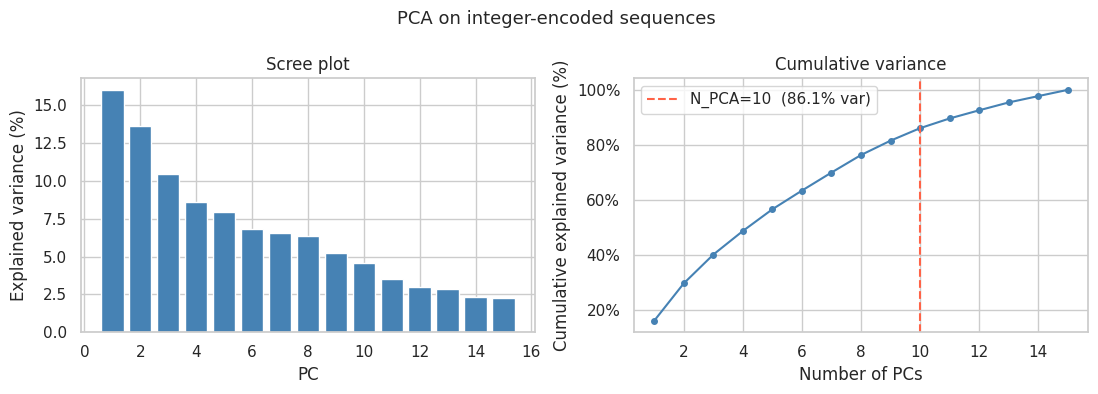

PCA: 15 → 10 dims  (86.1% variance retained)


In [15]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr    = pca_full.explained_variance_ratio_
cumevr = np.cumsum(evr)
n_comps = len(evr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(range(1, n_comps+1), evr * 100, color='steelblue')
ax1.set_xlabel('PC'); ax1.set_ylabel('Explained variance (%)')
ax1.set_title('Scree plot')

ax2.plot(range(1, n_comps+1), cumevr * 100, marker='o', color='steelblue', ms=4)
if N_PCA is not None:
    ax2.axvline(N_PCA, color='tomato', linestyle='--',
                label=f'N_PCA={N_PCA}  ({cumevr[N_PCA-1]*100:.1f}% var)')
    ax2.legend()
ax2.set_xlabel('Number of PCs'); ax2.set_ylabel('Cumulative explained variance (%)')
ax2.set_title('Cumulative variance')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('PCA on integer-encoded sequences', fontsize=13)
plt.tight_layout()
plt.show()

if N_PCA is not None and N_PCA < X_scaled.shape[1]:
    pca_reduce = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
    X_pca = pca_reduce.fit_transform(X_scaled)
    print(f'PCA: {X_scaled.shape[1]} → {N_PCA} dims  '
          f'({cumevr[N_PCA-1]*100:.1f}% variance retained)')
else:
    X_pca = X_scaled
    print('PCA skipped — using full scaled matrix')

### 6.4 t-SNE

In [16]:
tsne = TSNE(
    n_components  = 2,
    perplexity    = min(PERPLEXITY, len(X_pca) - 1),
    learning_rate = LEARNING_RATE,
    random_state  = RANDOM_STATE,
    init          = 'pca',
    verbose       = 1,
)
X_tsne = tsne.fit_transform(X_pca)
df_ok  = df_ok.assign(tsne_x=X_tsne[:, 0], tsne_y=X_tsne[:, 1])
print('t-SNE done. KL divergence:', round(tsne.kl_divergence_, 4))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 430 samples in 0.004s...
[t-SNE] Computed neighbors for 430 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 430 / 430
[t-SNE] Mean sigma: 1.671363
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.279549
[t-SNE] KL divergence after 1000 iterations: 0.311106
t-SNE done. KL divergence: 0.3111


### 6.5 t-SNE map — coloured by group (source/protocol)

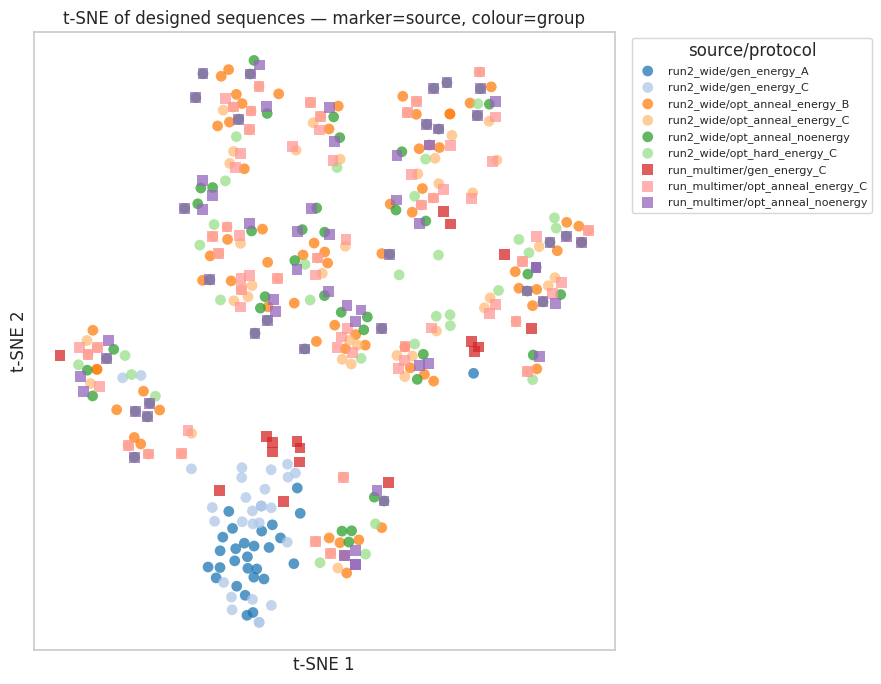

In [17]:
groups   = sorted(df_ok['group'].unique())
palette  = dict(zip(groups, sns.color_palette('tab20', len(groups))))
markers  = ['o', 's', 'D', 'H', 'P', 'X', '*', '>', '<', '^', 'v', ',']

# Assign marker by source
sources_list = sorted(df_ok['source'].unique())
src_marker   = dict(zip(sources_list, markers))

fig, ax = plt.subplots(figsize=(9, 7))
for grp, sub in df_ok.groupby('group'):
    src = sub['source'].iloc[0]
    ax.scatter(
        sub['tsne_x'], sub['tsne_y'],
        color      = palette[grp],
        marker     = src_marker.get(src, 'o'),
        s          = 60,
        alpha      = 0.75,
        label      = grp,
        edgecolors = 'none',
    )

ax.legend(title='source/protocol', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=8)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE of designed sequences — marker=source, colour=group')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### 6.6 t-SNE map — coloured by quality metrics

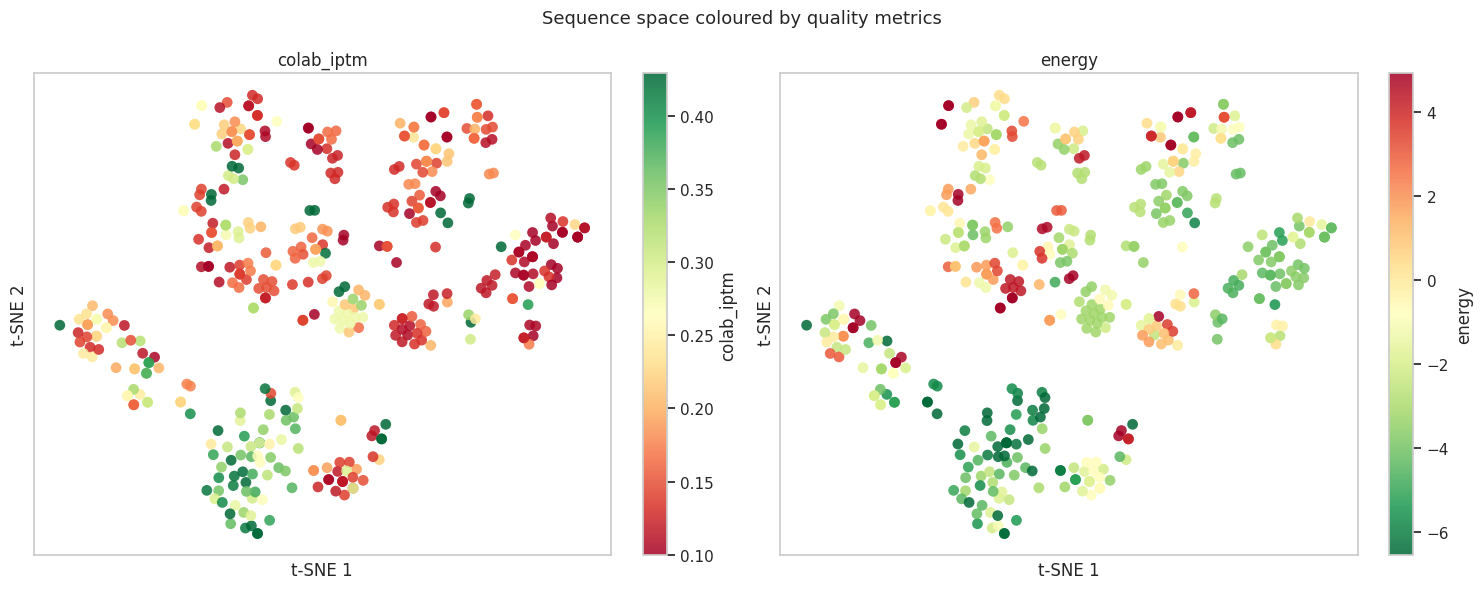

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (col, cmap) in zip(axes, [('colab_iptm', 'RdYlGn'), ('energy', 'RdYlGn_r')]):
    vals = df_ok[col]
    sc = ax.scatter(
        df_ok['tsne_x'], df_ok['tsne_y'],
        c          = vals,
        cmap       = cmap,
        s          = 60,
        alpha      = 0.85,
        vmin       = vals.quantile(0.05),
        vmax       = vals.quantile(0.95),
        edgecolors = 'none',
    )
    plt.colorbar(sc, ax=ax, label=col, fraction=0.04)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(col)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Sequence space coloured by quality metrics', fontsize=13)
plt.tight_layout()
plt.show()